 Wine Quality Prediction Using SVM, random forset ,XG boost,logistic Regrassin Clasfiction Full End-to-End Project 

import libarires


In [69]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np 
import pandas as pd 
import matplotlib .pyplot as plt 
import seaborn as sns
import plotly.express as px
from sklearn. preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)
from sklearn.impute import SimpleImputer
import joblib

load data 

In [70]:
red = pd.read_csv(r"C:\Users\yosef\Documents\joe\winequality-red.csv", sep=";")
white = pd.read_csv(r"C:\Users\yosef\Documents\joe\winequality-white.csv", sep=";")

red["type"] = "red"
white["type"] = "white"

df = pd.concat([red, white], ignore_index=True)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


Data Understanding

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [72]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [73]:
df.shape

(6497, 13)

Missing value & Duplicate

In [74]:
Null_num = df.isnull().sum()
Null_num

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

In [75]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 1177


In [76]:
df[df.duplicated()]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.99780,3.51,0.56,9.400000,5,red
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.99780,3.35,0.80,10.500000,5,red
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.99660,3.17,0.91,9.500000,5,red
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.99780,3.33,0.83,10.500000,5,red
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.900000,5,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6427,6.4,0.230,0.35,10.30,0.042,54.0,140.0,0.99670,3.23,0.47,9.200000,5,white
6449,7.0,0.360,0.35,2.50,0.048,67.0,161.0,0.99146,3.05,0.56,11.100000,6,white
6450,6.4,0.330,0.44,8.90,0.055,52.0,164.0,0.99488,3.10,0.48,9.600000,5,white
6455,7.1,0.230,0.39,13.70,0.058,26.0,172.0,0.99755,2.90,0.46,9.000000,6,white


In [77]:
df[df.duplicated(keep=False)]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.400000,5,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.400000,5,red
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.99780,3.35,0.80,10.500000,5,red
11,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.99780,3.35,0.80,10.500000,5,red
22,7.9,0.43,0.21,1.6,0.106,10.0,37.0,0.99660,3.17,0.91,9.500000,5,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6450,6.4,0.33,0.44,8.9,0.055,52.0,164.0,0.99488,3.10,0.48,9.600000,5,white
6454,7.1,0.23,0.39,13.7,0.058,26.0,172.0,0.99755,2.90,0.46,9.000000,6,white
6455,7.1,0.23,0.39,13.7,0.058,26.0,172.0,0.99755,2.90,0.46,9.000000,6,white
6478,6.6,0.34,0.40,8.1,0.046,68.0,170.0,0.99494,3.15,0.50,9.533333,6,white


In [78]:
print("Before:", df.shape)

df = df.drop_duplicates()

print("After:", df.shape)

Before: (6497, 13)
After: (5320, 13)


In [79]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'type'],
      dtype='object')

In [80]:
#check outliers
numeric_cols=df.select_dtypes(include="number").columns
fig=px.box(df,y=numeric_cols)
fig.show()

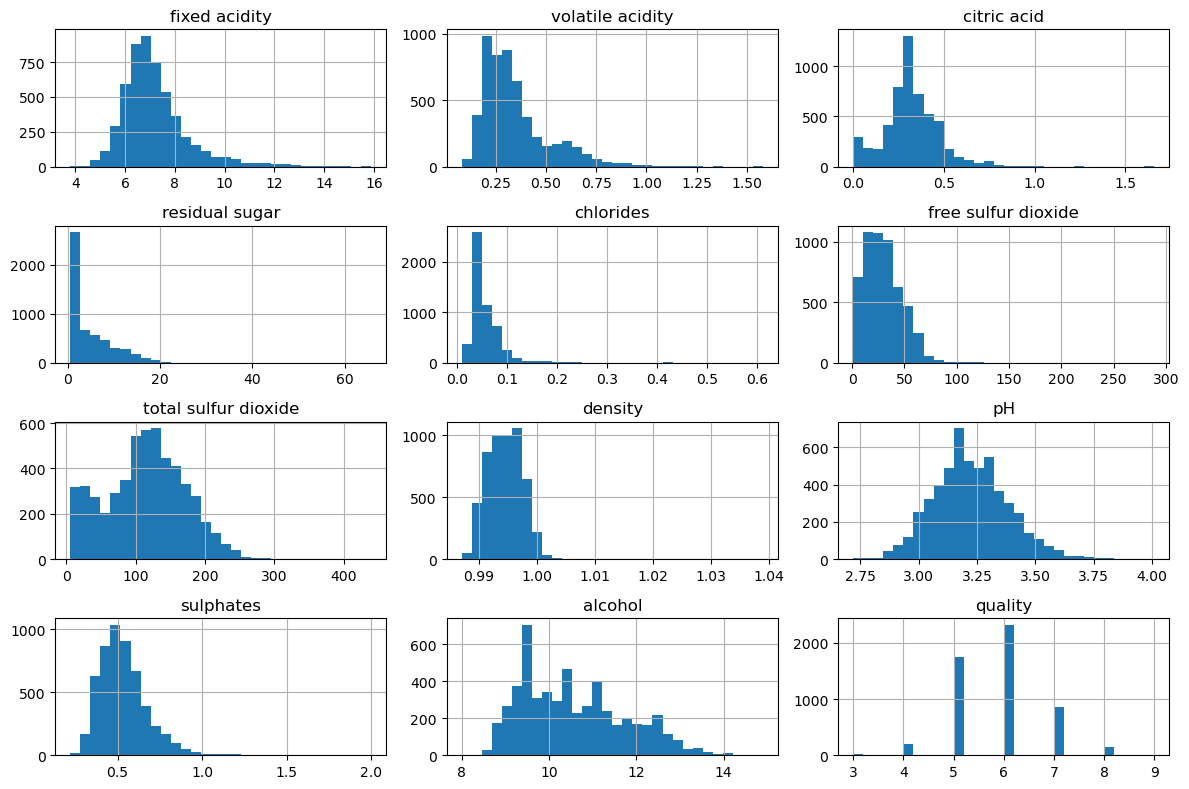

In [81]:
df.hist(figsize=(12, 8),bins=30)
plt.tight_layout()
plt.show()

Handle outliers

In [82]:
cols= ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol']
for col in cols:
 df[col] = np.log1p(df[col])

In [83]:
numeric_cols =df.select_dtypes(include="number").columns.drop("quality")
fig = px.box(df,y=numeric_cols)
fig.show()

In [84]:
cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

In [85]:
numeric_cols =df.select_dtypes(include="number").columns.drop("quality")
fig = px.box(df,y=numeric_cols)
fig.show()

In [86]:
#relation between columns
corr=df.corr(numeric_only=True)
print(corr)

                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000          0.225782     0.298961   
volatile acidity           0.225782          1.000000    -0.412811   
citric acid                0.298961         -0.412811     1.000000   
residual sugar            -0.078882         -0.136180     0.137366   
chlorides                  0.408856          0.518556    -0.070760   
free sulfur dioxide       -0.318618         -0.399585     0.131475   
total sulfur dioxide      -0.359656         -0.467157     0.210095   
density                    0.484496          0.316901     0.076867   
pH                        -0.285840          0.230017    -0.354278   
sulphates                  0.277490          0.253429     0.030070   
alcohol                   -0.125457         -0.067606     0.001022   
quality                   -0.099963         -0.257857     0.115578   

                      residual sugar  chlorides  free sulfur dioxide  \
fixed acidity    

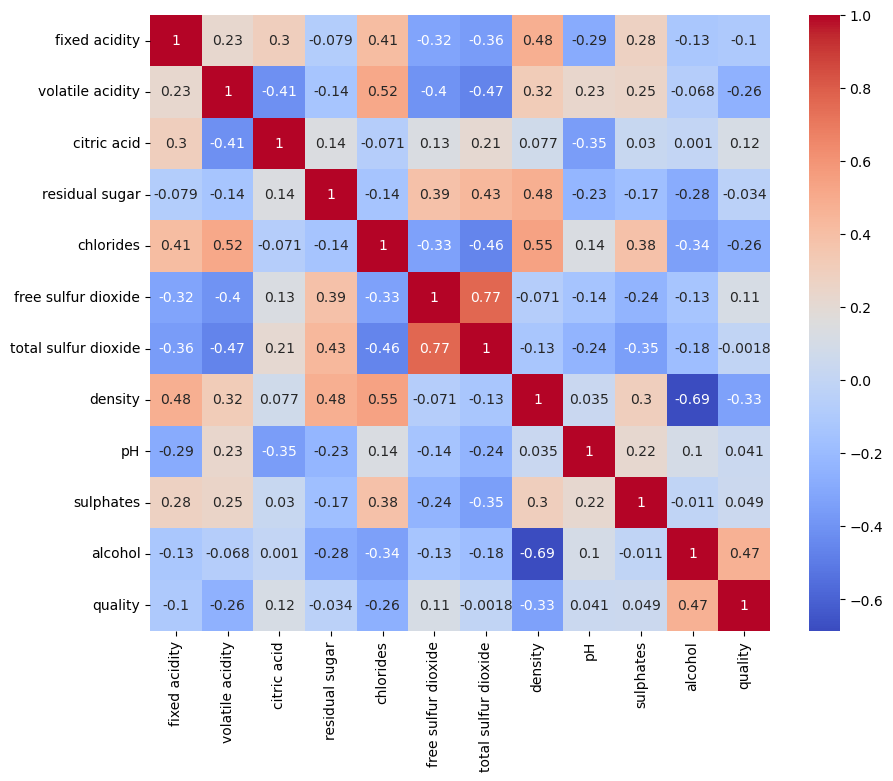

In [87]:
plt .figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.show()

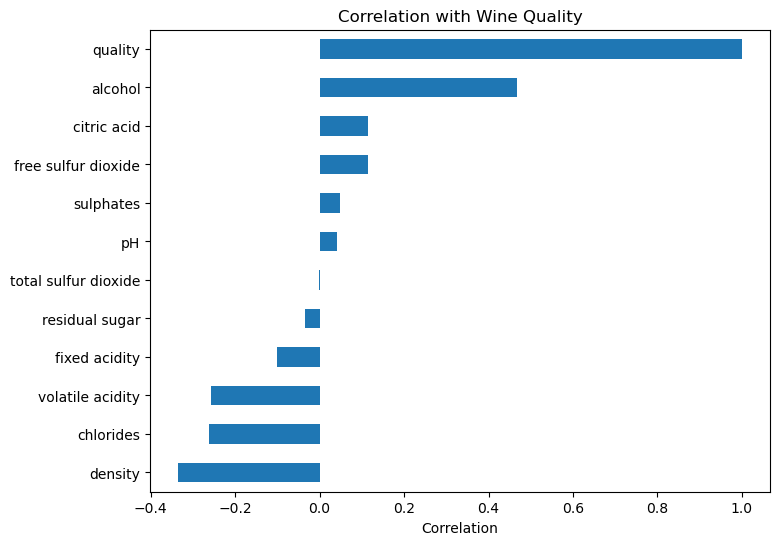

In [88]:


corr = df.corr(numeric_only=True)["quality"].sort_values()

plt.figure(figsize=(8,6))
corr.plot(kind="barh")
plt.title("Correlation with Wine Quality")
plt.xlabel("Correlation")
plt.show()

 ## Feature Engineering — acidity_alcohol_ratio


In [89]:
df["acidity_alcohol_ratio"] = df["fixed acidity"] / df["alcohol"]

 ## Feature Engineering — Total_sulfur


In [90]:
df["total_sulfur"] = (
    df["free sulfur dioxide"] +
    df["total sulfur dioxide"]
)

In [91]:
# acidity_differece
df["acidity_difference"] = (
    df["fixed acidity"] -
    df["volatile acidity"]
)

In [92]:
df["sugar_alcohol_ratio"] = (
    df["residual sugar"] /
    df["alcohol"]
)

In [93]:
df["acidity_index"] = (
    df["fixed acidity"] +
    df["volatile acidity"] +
    df["citric acid"]
)

In [94]:
df["density_alcohol"] = (
    df["density"] *
    df["alcohol"]
)

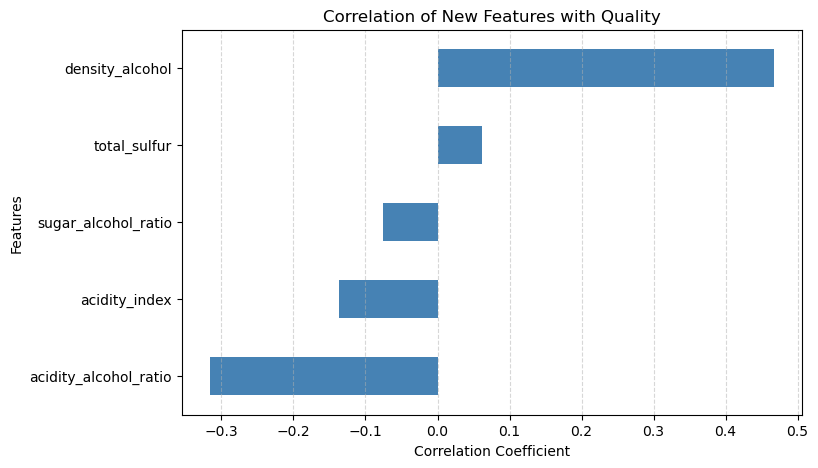

In [95]:
new_features = [
    "acidity_alcohol_ratio",
    "sugar_alcohol_ratio",
    "total_sulfur",
    "acidity_index",
    "density_alcohol"
]

corr = df[new_features + ["quality"]].corr()["quality"].drop("quality")

plt.figure(figsize=(8,5))
corr.sort_values().plot(kind="barh", color="steelblue")

plt.title("Correlation of New Features with Quality")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

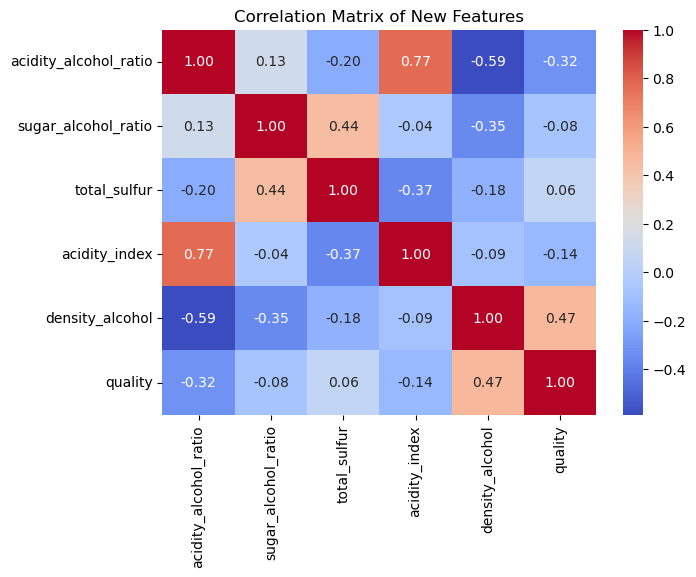

In [96]:
cols = new_features + ["quality"]

plt.figure(figsize=(7,5))

sns.heatmap(
    df[cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of New Features")
plt.show()

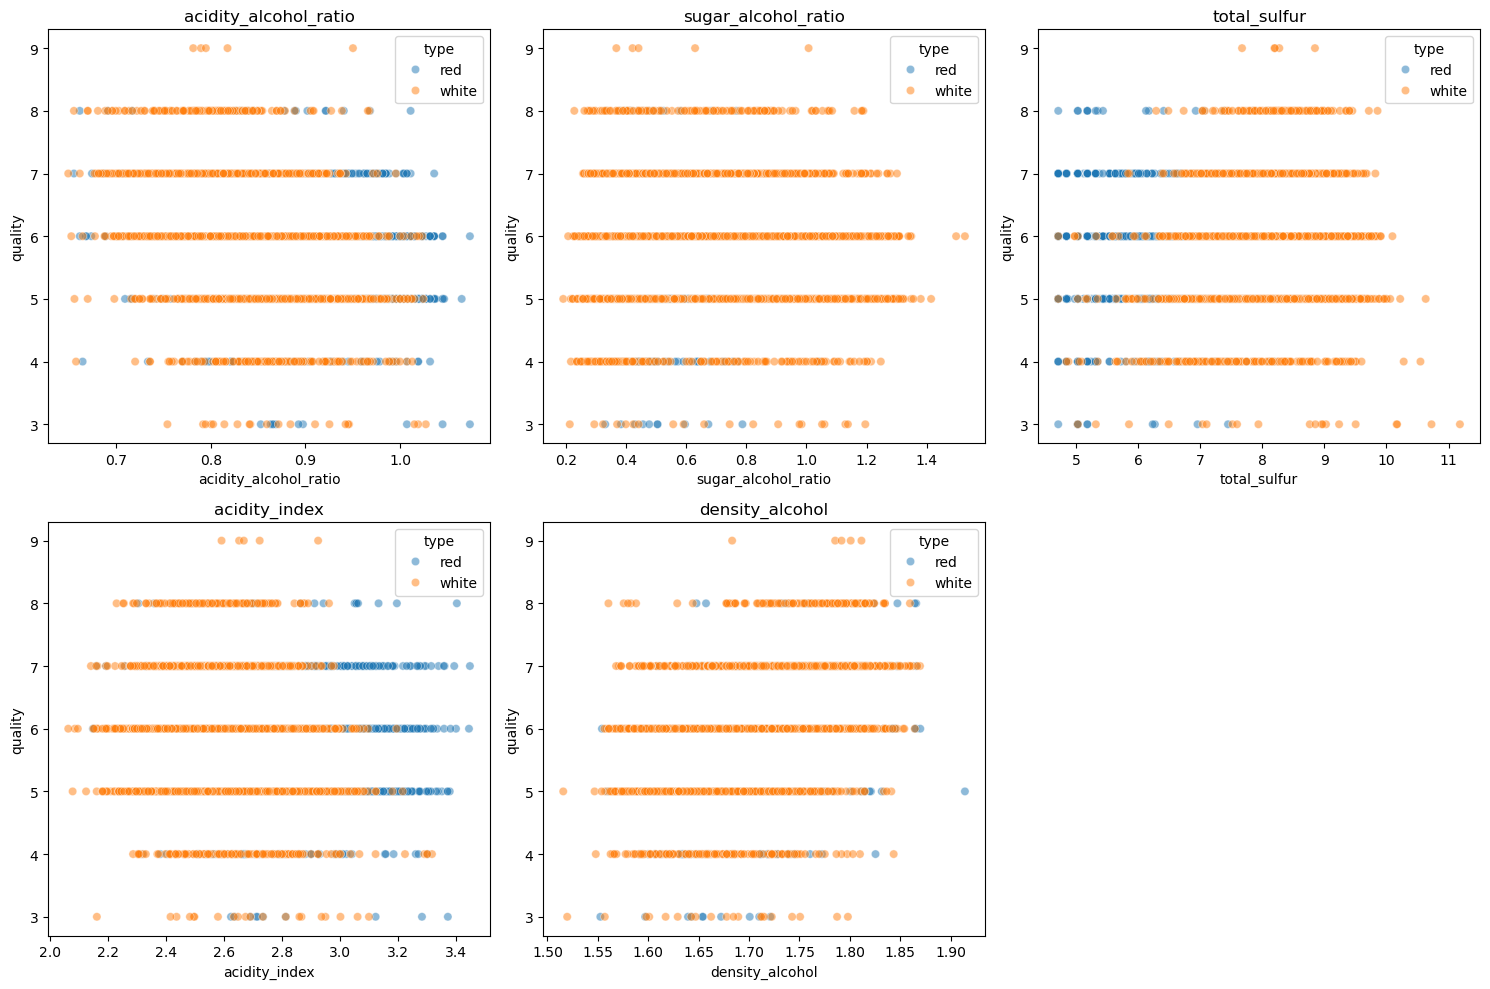

In [97]:


new_features = [
    "acidity_alcohol_ratio",
    "sugar_alcohol_ratio",
    "total_sulfur",
    "acidity_index",
    "density_alcohol"
]

plt.figure(figsize=(15,10))

for i, feature in enumerate(new_features, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(data=df,x=feature,y="quality", hue="type",alpha=0.5)
    plt.title(feature)

plt.tight_layout()
plt.show()

label encoder 


In [98]:
le = LabelEncoder()
df["type"] = le.fit_transform(df["type"])

In [121]:
le = LabelEncoder()

y = le.fit_transform(y)

🎯 Split Data


In [120]:
X = df.drop("quality", axis=1)
y = df["quality"]

✂️ Train-Test Split

In [122]:
x_train,x_test,y_train,y_test =train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

🔗 ML Pipeline

In [102]:
pipe_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

🏋️ Model Training

In [103]:
pipe_lr.fit(x_train,y_train)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [104]:
y_pred_train1=pipe_lr.predict(x_train)
y_pred_test1=pipe_lr.predict(x_test)

📊 Model Evaluation

In [105]:
print("Train Accuracy:", accuracy_score(y_train, y_pred_train1))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test1))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_pred_test1))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test1))

print("Precision:", precision_score(y_test, y_pred_test1, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_test1, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred_test1, average="weighted"))

Train Accuracy: 0.5570958646616542
Test Accuracy: 0.543233082706767

Confusion Matrix (Test):
[[  0   0   3   2   1   0   0]
 [  0   2  29  10   0   0   0]
 [  0   0 223 123   4   0   0]
 [  0   0 129 308  28   0   0]
 [  0   0  10 116  45   0   0]
 [  0   0   1  17  12   0   0]
 [  0   0   0   1   0   0   0]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       1.00      0.05      0.09        41
           5       0.56      0.64      0.60       350
           6       0.53      0.66      0.59       465
           7       0.50      0.26      0.34       171
           8       0.00      0.00      0.00        30
           9       0.00      0.00      0.00         1

    accuracy                           0.54      1064
   macro avg       0.37      0.23      0.23      1064
weighted avg       0.54      0.54      0.51      1064

Precision: 0.5378851892746588
Recall   : 0.543233082706767
F1 Score

🔗 ML Pipeline

In [106]:
pipe_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", RandomForestClassifier(random_state=42))
])
param_grid = {
   
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}


grid = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

grid.fit(x_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
{'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}
0.5686085963489514


🏋️ Model Training

In [107]:
grid.fit(x_train,y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [10, 20], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,missing_values,nan


In [139]:
pipe_rf.fit(x_train,y_train)

,steps,"[('imputer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,n_estimators,100


In [108]:
y_pred_train2=grid.predict(x_train)
y_pred_test2=grid.predict(x_test)

📊 Model Evaluation

In [109]:
print("Train Accuracy:", accuracy_score(y_train, y_pred_train2))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test2))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_pred_test2))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test2))

print("Precision:", precision_score(y_test, y_pred_test2, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_test2, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred_test2, average="weighted"))

Train Accuracy: 0.9715695488721805
Test Accuracy: 0.5733082706766918

Confusion Matrix (Test):
[[  0   0   4   2   0   0   0]
 [  0   2  28  11   0   0   0]
 [  0   2 240 107   1   0   0]
 [  0   0 119 315  31   0   0]
 [  0   0   2 117  52   0   0]
 [  0   0   0  19  10   1   0]
 [  0   0   0   1   0   0   0]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.50      0.05      0.09        41
           5       0.61      0.69      0.65       350
           6       0.55      0.68      0.61       465
           7       0.55      0.30      0.39       171
           8       1.00      0.03      0.06        30
           9       0.00      0.00      0.00         1

    accuracy                           0.57      1064
   macro avg       0.46      0.25      0.26      1064
weighted avg       0.58      0.57      0.55      1064

Precision: 0.5779242269936966
Recall   : 0.5733082706766918
F1 Sco

🔗 ML Pipeline

In [110]:
pipe_svm=Pipeline([
    ("imputer",SimpleImputer(strategy="mean")),
    ("scaler",StandardScaler()),
    ("model",SVC(kernel="rbf", C=1, gamma="scale"))
])

🏋️ Model Training

In [111]:
pipe_svm.fit(x_train,y_train)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [112]:
y_pred_train3=pipe_svm.predict(x_train)
y_pred_test3=pipe_svm.predict(x_test)

📊 Model Evaluation

In [113]:
print("Train Accuracy:", accuracy_score(y_train, y_pred_train3))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test3))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_pred_test3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test3))

print("Precision:", precision_score(y_test, y_pred_test3, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_test3, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred_test3, average="weighted"))

Train Accuracy: 0.6033834586466166
Test Accuracy: 0.5535714285714286

Confusion Matrix (Test):
[[  0   0   3   3   0   0   0]
 [  0   0  33   8   0   0   0]
 [  0   0 231 119   0   0   0]
 [  0   0 124 319  22   0   0]
 [  0   0   6 126  39   0   0]
 [  0   0   0  19  11   0   0]
 [  0   0   0   1   0   0   0]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00        41
           5       0.58      0.66      0.62       350
           6       0.54      0.69      0.60       465
           7       0.54      0.23      0.32       171
           8       0.00      0.00      0.00        30
           9       0.00      0.00      0.00         1

    accuracy                           0.55      1064
   macro avg       0.24      0.22      0.22      1064
weighted avg       0.51      0.55      0.52      1064

Precision: 0.5127630770258521
Recall   : 0.5535714285714286
F1 Sco

model build

In [123]:
from xgboost import XGBClassifier

model = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss",
    max_depth=3,          
    learning_rate=0.05,   
    n_estimators=200,
    subsample=0.8,        
    colsample_bytree=0.8, 
    min_child_weight=3,
    reg_alpha=0.1,        
    reg_lambda=1.0       
)


🏋️ Model Training

In [124]:
model.fit(x_train,y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'mlogloss'


In [125]:
y_pred_test4 = model.predict(x_test)
y_pred_train4 = model.predict(x_train)

📊 Model Evaluation

In [126]:
print("Train Accuracy:", accuracy_score(y_train, y_pred_train4))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test4))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_pred_test4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test4))

print("Precision:", precision_score(y_test, y_pred_test4, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_test4, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred_test4, average="weighted"))

Train Accuracy: 0.6475563909774437
Test Accuracy: 0.556390977443609

Confusion Matrix (Test):
[[  0   0   5   0   1   0   0]
 [  0   2  30   9   0   0   0]
 [  1   0 231 118   0   0   0]
 [  0   1 125 314  25   0   0]
 [  0   0   5 121  45   0   0]
 [  0   0   1  17  12   0   0]
 [  0   0   0   1   0   0   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.67      0.05      0.09        41
           2       0.58      0.66      0.62       350
           3       0.54      0.68      0.60       465
           4       0.54      0.26      0.35       171
           5       0.00      0.00      0.00        30
           6       0.00      0.00      0.00         1

    accuracy                           0.56      1064
   macro avg       0.33      0.24      0.24      1064
weighted avg       0.54      0.56      0.53      1064

Precision: 0.5408251400040183
Recall   : 0.556390977443609
F1 Score

In [127]:
#model test
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="mlogloss"
    )
}

for name, model in models.items():
    
    
    model.fit(x_train, y_train)

   
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

   
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    print(f"\n{name}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy : {test_acc:.4f}")


Random Forest
Train Accuracy: 1.0000
Test Accuracy : 0.5677

Logistic Regression
Train Accuracy: 0.5524
Test Accuracy : 0.5301

SVM
Train Accuracy: 0.5026
Test Accuracy : 0.5028

XGBoost
Train Accuracy: 0.9984
Test Accuracy : 0.5620


In [ ]:
#visualltion  model train , test
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Logistic Regression",
        "SVM",
        "XGBoost"
    ],
    "Train Accuracy": [
        1.0000,
        0.5336,
        0.4976,
        0.9950
    ],
    "Test Accuracy": [
        0.6962,
        0.5246,
        0.4869,
        0.6677
    ]
})


In [ ]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="mlogloss")
}
results = []

for name, model in models.items():
    model.fit(x_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(x_train))
    test_acc = accuracy_score(y_test, model.predict(x_test))

    results.append([name, train_acc, test_acc])

results = pd.DataFrame(
    results,
    columns=["Model", "Train Accuracy", "Test Accuracy"]
)

print(results)

                 Model  Train Accuracy  Test Accuracy
0        Random Forest        1.000000       0.696154
1  Logistic Regression        0.533577       0.524615
2                  SVM        0.497595       0.486923
3              XGBoost        0.994997       0.667692


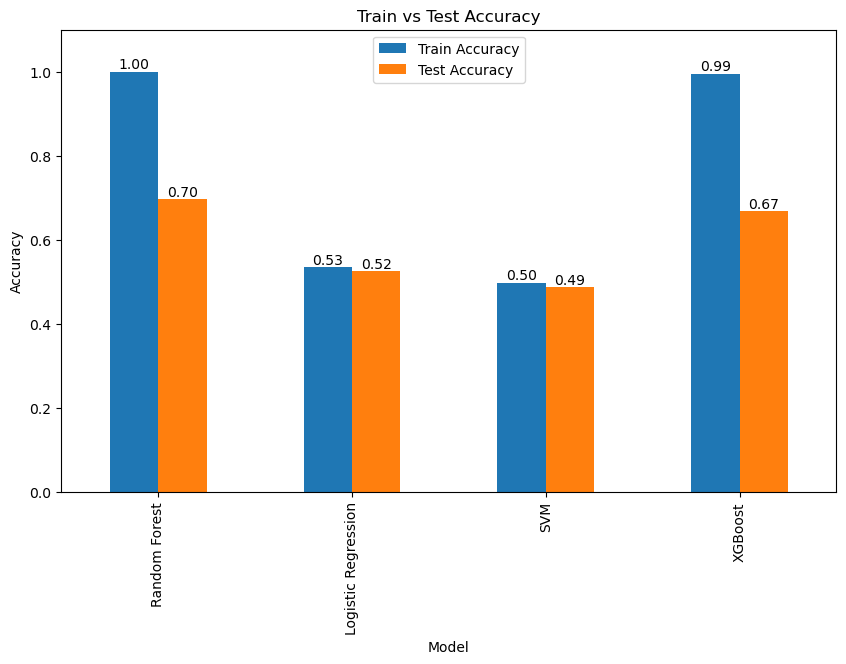

In [ ]:
ax = results.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Train vs Test Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.show()

save model

In [129]:
model1 = {
    "logistic_pipeline.pkl": pipe_lr,
    "random_forest_pipeline.pkl": pipe_rf,
    "svm_pipeline.pkl": pipe_svm,
    "xgboost_pipeline.pkl": model
}

for filename, model in models.items():
    joblib.dump(model, filename)

print("All pipelines saved successfully.")

All pipelines saved successfully.


In [132]:
def load_encoders():
    type_encoder = joblib.load("type_encoder.pkl")
    target_encoder = joblib.load("target_encoder.pkl")
    return type_encoder, target_encoder

In [134]:
joblib.dump(y, "target_encoder.pkl")

['target_encoder.pkl']

In [135]:
import os
import joblib
import json
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

os.makedirs("models", exist_ok=True)

# حفظ الموديلات
joblib.dump(pipe_lr, "models/logistic_pipeline.pkl")
joblib.dump(pipe_rf, "models/random_forest_pipeline.pkl")
joblib.dump(pipe_svm, "models/svm_pipeline.pkl")
joblib.dump(model, "models/xgboost_pipeline.pkl")

print("Models Saved")

Models Saved


In [136]:
df.to_csv("processed_data.csv", index=False)

In [140]:
results = []

reports = {}

trained_models = {
    "Logistic Regression": pipe_lr,
    "Random Forest": pipe_rf,
    "SVM": pipe_svm,
    "XGBoost": model
}

for name, m in trained_models.items():

    pred_train = m.predict(x_train)
    pred_test = m.predict(x_test)

    results.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, pred_train),
        "Test Accuracy": accuracy_score(y_test, pred_test),
        "Precision": precision_score(y_test, pred_test, average="weighted"),
        "Recall": recall_score(y_test, pred_test, average="weighted"),
        "F1 Score": f1_score(y_test, pred_test, average="weighted")
    })

    reports[name] = {
        "confusion_matrix": confusion_matrix(y_test, pred_test).tolist(),
        "classification_report": classification_report(
            y_test,
            pred_test,
            output_dict=True
        ),
        "classes": sorted(np.unique(y_test).tolist())
    }

metadata = {
    "feature_cols": list(x_train.columns),
    "results": results,
    "reports": reports,
    "n_samples": len(df)
}

with open("metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("metadata.json Saved")

metadata.json Saved
